# House Price Prediction — Linear Regression From Scratch

Notebook này giải bài toán dự đoán `SalePrice` bằng **hồi quy tuyến tính tự cài đặt với NumPy**. Mục tiêu không chỉ là có một file submission, mà còn làm rõ dữ liệu đi qua từng bước như thế nào, vì sao mỗi quyết định hợp lý, và cách kiểm chứng chương trình không bị data leakage.

Chuỗi thí nghiệm:

```text
mean baseline
    ↓
linear regression 1 biến (GrLivArea)
    ↓
multiple linear regression với toàn bộ features
    ↓
feature engineering + 5-fold cross-validation
    ↓
fit toàn bộ train và tạo submission.csv
```

Các quyết định đã thống nhất:

- dùng toàn bộ biến numeric và categorical, trừ `Id`;
- huấn luyện trên `log1p(SalePrice)` và chọn mô hình bằng log-RMSE;
- tự viết standardization, metrics, one-hot schema và gradient descent;
- scikit-learn chỉ hỗ trợ split/K-fold và đối chiếu kiểm thử;
- giữ outlier để phân tích, không xóa theo nhãn;
- random seed cố định là `42`.

## 1. Thiết lập môi trường và đọc dữ liệu

Notebook hỗ trợ chạy từ thư mục gốc workspace, từ chính thư mục `House-Price-Prediction`, hoặc trên Kaggle. Cache được đặt trong workspace để không ghi vào home chỉ-đọc.

In [1]:
import os
import platform
from pathlib import Path
from itertools import product

workspace_cache = Path.cwd() / ".cache"
workspace_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(workspace_cache))
os.environ.setdefault("MPLCONFIGDIR", str(workspace_cache / "matplotlib"))
os.environ.setdefault("JUPYTER_CONFIG_DIR", str(workspace_cache / "jupyter"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold, train_test_split

SEED = 42
np.random.seed(SEED)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")

print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

Python: 3.14.4
NumPy: 2.5.1
pandas: 3.0.5


In [2]:
DATA_CANDIDATES = [
    Path("data"),
    Path("House-Price-Prediction/data"),
    Path("/kaggle/input/house-prices-advanced-regression-techniques"),
]
DATA_DIR = next(
    (path for path in DATA_CANDIDATES if (path / "train.csv").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Không tìm thấy train.csv. Hãy chạy notebook trong workspace hoặc gắn dữ liệu Kaggle."
    )

train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

assert "SalePrice" in train_df and "SalePrice" not in test_df
assert train_df.drop(columns="SalePrice").columns.equals(test_df.columns)
assert train_df["Id"].is_unique and test_df["Id"].is_unique

print("Data directory:", DATA_DIR.resolve())
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
display(train_df.head())

Data directory: /home/drago/projects/Machine-Learning-Deep-Learning/House-Price-Prediction/data
Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. EDA có trọng tâm

Ta cần trả lời sáu câu hỏi trước khi mô hình hóa:

1. Dữ liệu có bao nhiêu mẫu và kiểu biến?
2. Target có lệch không?
3. Missing tập trung ở đâu và có mang ý nghĩa “không có tiện ích” không?
4. Biến numeric nào liên hệ mạnh với giá?
5. Có outlier đáng chú ý không?
6. Train/test có cùng schema không?

`Id` là khóa định danh cho submission, không phải đặc trưng về căn nhà nên được loại khỏi mô hình.

In [3]:
X_overview = train_df.drop(columns=["SalePrice", "Id"])
overview = pd.Series({
    "Số mẫu train": len(train_df),
    "Số predictors (không tính Id)": X_overview.shape[1],
    "Biến numeric": X_overview.select_dtypes(include="number").shape[1],
    "Biến categorical": X_overview.select_dtypes(exclude="number").shape[1],
    "Cột có missing ở train": X_overview.isna().any().sum(),
    "Cột có missing ở test": test_df.drop(columns="Id").isna().any().sum(),
    "Dòng trùng hoàn toàn": train_df.duplicated().sum(),
})
display(overview.to_frame("Giá trị"))

target_summary = train_df["SalePrice"].describe().to_frame("SalePrice")
target_summary.loc["skew"] = train_df["SalePrice"].skew()
display(target_summary)

,Giá trị
Số mẫu train,1460
Số predictors (không tính Id),79
Biến numeric,36
Biến categorical,43
Cột có missing ở train,19
Cột có missing ở test,33
Dòng trùng hoàn toàn,0


,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000
skew,1.882876


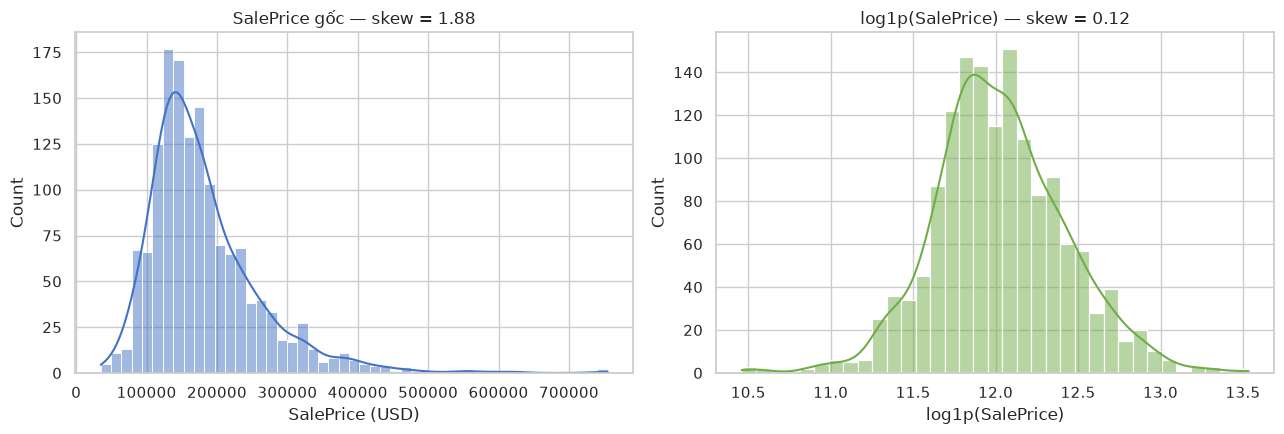

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train_df["SalePrice"], kde=True, ax=axes[0], color="#4472C4")
axes[0].set_title(f"SalePrice gốc — skew = {train_df['SalePrice'].skew():.2f}")
axes[0].set_xlabel("SalePrice (USD)")

sale_price_log = np.log1p(train_df["SalePrice"])
sns.histplot(sale_price_log, kde=True, ax=axes[1], color="#70AD47")
axes[1].set_title(f"log1p(SalePrice) — skew = {sale_price_log.skew():.2f}")
axes[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()
plt.show()

,train_pct,test_pct
PoolQC,99.52,99.79
MiscFeature,96.30,96.50
Alley,93.77,92.67
Fence,80.75,80.12
MasVnrType,59.73,61.27
FireplaceQu,47.26,50.03
LotFrontage,17.74,15.56
GarageType,5.55,5.21
GarageQual,5.55,5.35
GarageFinish,5.55,5.35


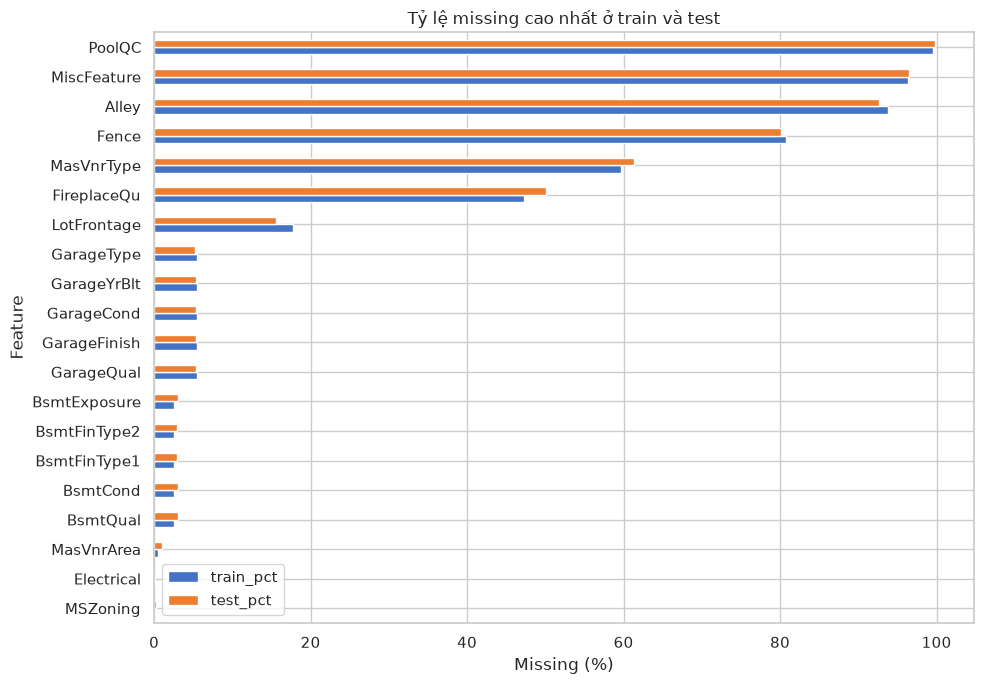

In [5]:
missing_summary = pd.DataFrame({
    "train_pct": train_df.drop(columns="SalePrice").isna().mean() * 100,
    "test_pct": test_df.isna().mean() * 100,
}).sort_values("train_pct", ascending=False)

top_missing = missing_summary[missing_summary.max(axis=1) > 0].head(20)
display(top_missing.round(2))

ax = top_missing.sort_values("train_pct").plot.barh(
    figsize=(10, 7), color=["#4472C4", "#ED7D31"]
)
ax.set_title("Tỷ lệ missing cao nhất ở train và test")
ax.set_xlabel("Missing (%)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

,corr_with_SalePrice
OverallQual,0.791
GrLivArea,0.709
GarageCars,0.640
GarageArea,0.623
TotalBsmtSF,0.614
1stFlrSF,0.606
FullBath,0.561
TotRmsAbvGrd,0.534
YearBuilt,0.523
YearRemodAdd,0.507


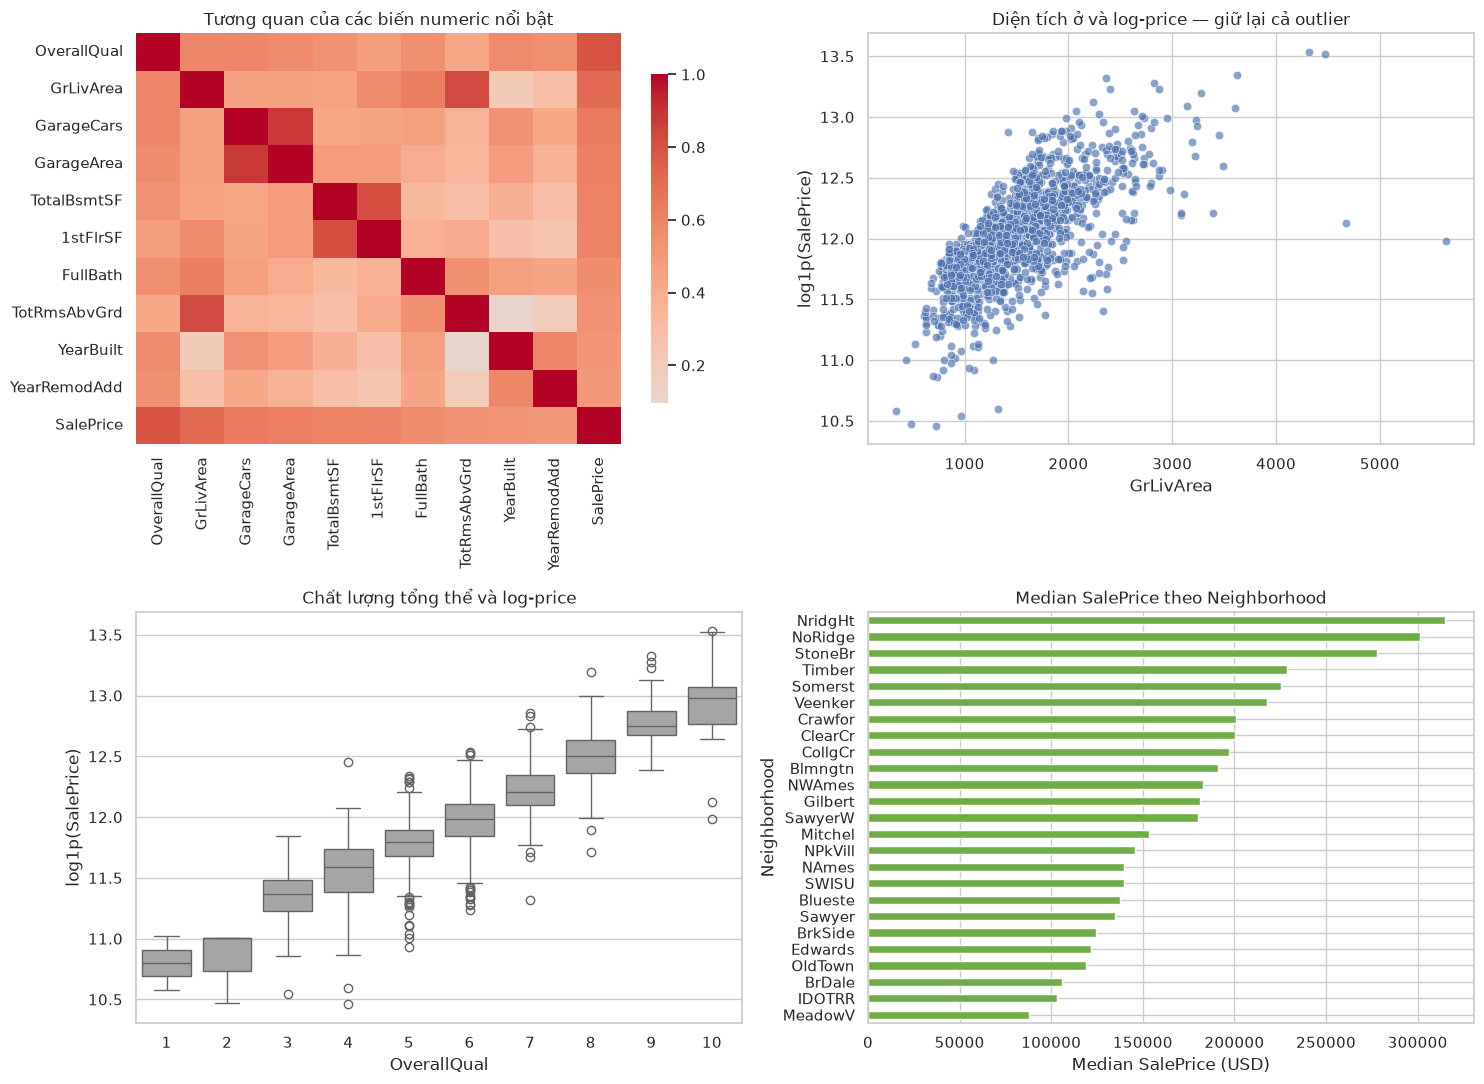

In [6]:
numeric_columns_eda = train_df.drop(columns="Id").select_dtypes(include="number").columns
corr_to_target = (
    train_df[numeric_columns_eda]
    .corr()["SalePrice"]
    .drop("SalePrice")
    .sort_values(key=np.abs, ascending=False)
)
top_numeric = corr_to_target.head(10).index.tolist()
display(corr_to_target.head(15).to_frame("corr_with_SalePrice").round(3))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sns.heatmap(
    train_df[top_numeric + ["SalePrice"]].corr(),
    cmap="coolwarm", center=0, ax=axes[0, 0], cbar_kws={"shrink": 0.8}
)
axes[0, 0].set_title("Tương quan của các biến numeric nổi bật")

sns.scatterplot(
    data=train_df, x="GrLivArea", y=np.log1p(train_df["SalePrice"]),
    alpha=0.65, ax=axes[0, 1]
)
axes[0, 1].set_title("Diện tích ở và log-price — giữ lại cả outlier")
axes[0, 1].set_ylabel("log1p(SalePrice)")

sns.boxplot(
    data=train_df, x="OverallQual", y=np.log1p(train_df["SalePrice"]),
    color="#A5A5A5", ax=axes[1, 0]
)
axes[1, 0].set_title("Chất lượng tổng thể và log-price")
axes[1, 0].set_ylabel("log1p(SalePrice)")

neighborhood_median = (
    train_df.groupby("Neighborhood", observed=True)["SalePrice"]
    .median().sort_values()
)
neighborhood_median.plot.barh(ax=axes[1, 1], color="#70AD47")
axes[1, 1].set_title("Median SalePrice theo Neighborhood")
axes[1, 1].set_xlabel("Median SalePrice (USD)")
plt.tight_layout()
plt.show()

### Kết luận EDA

- `SalePrice` lệch phải mạnh; `log1p` làm phân phối gần đối xứng và phù hợp metric của bài toán.
- Missing không đồng nhất về ý nghĩa. Với garage, basement, pool, fireplace…, missing thường nghĩa là căn nhà **không có** hạng mục đó. Các trường hợp này không nên trộn với missing thật.
- `OverallQual`, `GrLivArea`, diện tích basement/tầng một và garage có liên hệ rõ với giá.
- Một vài điểm diện tích rất lớn có residual tiềm năng cao. Ta giữ chúng để đánh giá trung thực độ nhạy của loss bình phương.
- Hồi quy tuyến tính chỉ mô tả quan hệ cộng tuyến tính sau encoding; tương quan hay hệ số lớn không chứng minh quan hệ nhân quả.

## 3. Target, holdout và metric

Với giá thật $y>0$, ta học:

$$y_{log}=\log(1+y)$$

Metric chính là RMSE trên log-price:

$$\text{log-RMSE}=\sqrt{\frac{1}{m}\sum_i(\hat y_{log,i}-y_{log,i})^2}$$

Holdout 80/20 dùng để minh họa learning curve và residual. Sau đó manual 5-fold CV được dùng để so sánh cấu hình ổn định hơn. Kaggle `test.csv` không có nhãn và tuyệt đối không tham gia chọn mô hình.

In [7]:
all_indices = np.arange(len(train_df))
train_indices, valid_indices = train_test_split(
    all_indices, test_size=0.20, random_state=SEED
)

y_price = train_df["SalePrice"].to_numpy(dtype=float)
y_log = np.log1p(y_price)

print("Local train:", len(train_indices))
print("Local valid:", len(valid_indices))
print("Mean log-price train/valid:", y_log[train_indices].mean(), y_log[valid_indices].mean())

Local train: 1168
Local valid: 292
Mean log-price train/valid: 12.030658310971573 11.997653730705732


## 4. Các khối ML tự xây dựng

Đây là các hàm cốt lõi từ bài tập tuần 3. Quy ước shape:

- `X`: `(m, n)` — `m` căn nhà, `n` features;
- `w`: `(n,)` — một trọng số cho mỗi feature;
- `b`: scalar — bias;
- `y`: `(m,)` — target.

Standardization phải fit trên train theo `axis=0`. Feature có độ lệch chuẩn bằng 0 được biến thành 0 để tránh chia cho 0.

In [8]:
def affine(X, W, b):
    X = np.asarray(X, dtype=float)
    W = np.asarray(W, dtype=float)
    b = np.asarray(b, dtype=float)
    if X.ndim != 2 or W.ndim != 2 or b.ndim != 1:
        raise ValueError("X, W, b phải lần lượt có ndim 2, 2, 1")
    if X.shape[1] != W.shape[0] or W.shape[1] != b.size:
        raise ValueError("Shape không tương thích cho X @ W + b")
    return X @ W + b


def fit_standardizer(X_train):
    X_train = np.asarray(X_train, dtype=float)
    if X_train.ndim != 2 or X_train.shape[0] == 0:
        raise ValueError("X_train phải có shape (m, n) và không rỗng")
    if not np.isfinite(X_train).all():
        raise ValueError("X_train chứa NaN hoặc inf")
    return X_train.mean(axis=0), X_train.std(axis=0, ddof=0)


def transform(X, mean, std):
    X = np.asarray(X, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)
    if X.ndim != 2 or mean.ndim != 1 or std.ndim != 1:
        raise ValueError("Shape mong đợi: X (m,n), mean (n,), std (n,)")
    if X.shape[1] != mean.size or mean.shape != std.shape:
        raise ValueError("Số features của X, mean và std phải khớp")
    zero_std = std == 0
    safe_std = np.where(zero_std, 1.0, std)
    standardized = (X - mean) / safe_std
    standardized[:, zero_std] = 0.0
    return standardized


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    if y_true.size == 0 or y_true.shape != y_pred.shape:
        raise ValueError("y_true và y_pred phải cùng shape và không rỗng")
    if not (np.isfinite(y_true).all() and np.isfinite(y_pred).all()):
        raise ValueError("Metric không nhận NaN/inf")

    error = y_true - y_pred
    mae = np.mean(np.abs(error))
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    ss_res = np.sum(error ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = (1.0 if ss_res == 0 else 0.0) if ss_tot == 0 else 1.0 - ss_res / ss_tot
    return float(mae), float(mse), float(rmse), float(r2)


def log_rmse(y_true_log, y_pred_log):
    return regression_metrics(y_true_log, y_pred_log)[2]

In [9]:
# Unit tests cho affine, standardization và metrics.
X_tiny = np.array([[1.0, 2.0], [3.0, 2.0], [5.0, 2.0]])
W_tiny = np.array([[2.0], [-1.0]])
b_tiny = np.array([0.5])
assert affine(X_tiny, W_tiny, b_tiny).shape == (3, 1)

mean_tiny, std_tiny = fit_standardizer(X_tiny)
Z_tiny = transform(X_tiny, mean_tiny, std_tiny)
assert np.allclose(Z_tiny.mean(axis=0), [0.0, 0.0])
assert np.allclose(Z_tiny[:, 1], 0.0)  # feature có std=0

y_check = np.array([10.0, 20.0, 30.0, 40.0])
p_check = np.array([12.0, 18.0, 33.0, 37.0])
mae_c, mse_c, rmse_c, r2_c = regression_metrics(y_check, p_check)
assert np.isclose(mae_c, mean_absolute_error(y_check, p_check))
assert np.isclose(mse_c, mean_squared_error(y_check, p_check))
assert np.isclose(rmse_c, np.sqrt(mean_squared_error(y_check, p_check)))
assert np.isclose(r2_c, r2_score(y_check, p_check))
print("PASS — core functions khớp tính tay/sklearn và xử lý std=0.")

PASS — core functions khớp tính tay/sklearn và xử lý std=0.


### 4.1 Hồi quy một biến bằng gradient descent

Với $\hat y=wx+b$ và $J=\frac{1}{2m}\sum(\hat y-y)^2$:

$$dw=\frac{1}{m}x^T(\hat y-y),\qquad db=\operatorname{mean}(\hat y-y)$$

In [10]:
def fit_linear_regression_1d(x, y, learning_rate, epochs):
    x = np.asarray(x, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    if x.size == 0 or x.shape != y.shape:
        raise ValueError("x và y phải cùng shape và không rỗng")
    if learning_rate <= 0 or epochs <= 0:
        raise ValueError("learning_rate và epochs phải dương")

    m = x.size
    w, b = 0.0, 0.0
    cost_history = []
    for _ in range(epochs):
        error = w * x + b - y
        cost_history.append(float(np.mean(error ** 2) / 2.0))
        dw = np.dot(x, error) / m
        db = np.mean(error)
        w -= learning_rate * dw
        b -= learning_rate * db
    final_error = w * x + b - y
    cost_history.append(float(np.mean(final_error ** 2) / 2.0))
    return float(w), float(b), np.asarray(cost_history)

### 4.2 Hồi quy đa biến vectorized

Mô hình:

$$\hat y=Xw+b$$

Gradient có shape đúng:

```text
X.T       @ error -> dw
(n, m)    @ (m,)  -> (n,)
```

Class dưới đây giữ API của bài tập tuần 3 và thêm tùy chọn không lưu toàn bộ history khi chạy grid search, giúp CV nhanh hơn mà không đổi thuật toán.

In [11]:
class LinearRegressionGD:
    def __init__(
        self,
        learning_rate=0.01,
        epochs=1000,
        standardize=True,
        record_history=True,
        history_interval=1,
    ):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.standardize = standardize
        self.record_history = record_history
        self.history_interval = history_interval

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        if X.ndim != 2 or X.shape[0] != y.size or y.size == 0:
            raise ValueError("X phải là (m,n), y là (m,) và cùng số samples")
        if not (np.isfinite(X).all() and np.isfinite(y).all()):
            raise ValueError("X/y chứa NaN hoặc inf")
        if self.learning_rate <= 0 or self.epochs <= 0 or self.history_interval <= 0:
            raise ValueError("learning_rate, epochs và history_interval phải dương")

        self.n_features_in_ = X.shape[1]
        if self.standardize:
            self.mean_, self.std_ = fit_standardizer(X)
            X_work = transform(X, self.mean_, self.std_)
        else:
            self.mean_ = np.zeros(X.shape[1])
            self.std_ = np.ones(X.shape[1])
            X_work = X

        m, n = X_work.shape
        self.w_ = np.zeros(n, dtype=float)
        self.b_ = 0.0
        initial_error = X_work @ self.w_ + self.b_ - y
        self.cost_history_ = [float(np.mean(initial_error ** 2) / 2.0)]
        self.history_epochs_ = [0]

        for epoch in range(1, self.epochs + 1):
            error = X_work @ self.w_ + self.b_ - y
            dw = X_work.T @ error / m
            db = np.mean(error)
            self.w_ -= self.learning_rate * dw
            self.b_ -= self.learning_rate * db

            if not (np.isfinite(self.w_).all() and np.isfinite(self.b_)):
                raise FloatingPointError(
                    "Gradient descent phân kỳ; hãy kiểm tra scaling/learning rate"
                )
            if self.record_history and (
                epoch % self.history_interval == 0 or epoch == self.epochs
            ):
                new_error = X_work @ self.w_ + self.b_ - y
                self.cost_history_.append(float(np.mean(new_error ** 2) / 2.0))
                self.history_epochs_.append(epoch)

        final_error = X_work @ self.w_ + self.b_ - y
        self.final_cost_ = float(np.mean(final_error ** 2) / 2.0)
        return self

    def predict(self, X):
        if not hasattr(self, "w_"):
            raise RuntimeError("Phải gọi fit trước predict")
        X = np.asarray(X, dtype=float)
        if X.ndim != 2 or X.shape[1] != self.n_features_in_:
            raise ValueError("X có số features không đúng")
        if not np.isfinite(X).all():
            raise ValueError("X chứa NaN hoặc inf")
        X_work = transform(X, self.mean_, self.std_) if self.standardize else X
        return X_work @ self.w_ + self.b_

In [12]:
# Mô hình phải học được dữ liệu tuyến tính tổng hợp gần hoàn hảo.
rng = np.random.default_rng(SEED)
X_syn = rng.normal(size=(300, 3))
y_syn = 3.0 * X_syn[:, 0] - 2.0 * X_syn[:, 1] + 0.5 * X_syn[:, 2] + 4.0
syn_model = LinearRegressionGD(learning_rate=0.05, epochs=1000).fit(X_syn, y_syn)
syn_pred = syn_model.predict(X_syn)
assert log_rmse(y_syn, syn_pred) < 1e-6

try:
    LinearRegressionGD().predict(X_syn)
except RuntimeError:
    pass
else:
    raise AssertionError("predict trước fit phải báo lỗi")

print("PASS — custom LinearRegressionGD học đúng dữ liệu tuyến tính tổng hợp.")

PASS — custom LinearRegressionGD học đúng dữ liệu tuyến tính tổng hợp.


## 5. Feature engineering và preprocessing tự quản lý schema

### Feature engineering

Bốn biến mới đều được tính độc lập trên từng căn nhà nên có thể tạo trước split mà không leakage:

- `TotalSF`: tổng diện tích basement, tầng một và tầng hai;
- `TotalBathrooms`: tổng số phòng tắm, phòng tắm nửa tính `0.5`;
- `HouseAgeAtSale`: tuổi nhà khi bán;
- `YearsSinceRemodel`: số năm từ lần sửa gần nhất đến khi bán.

### Missing theo ngữ nghĩa

- Nhóm không có garage/basement/pool…: categorical → `None`, numeric → `0`.
- Missing thật: numeric → median, categorical → mode **của train**.

`MSSubClass` là mã loại nhà và `MoSold` là tháng; ta one-hot thay vì ép mô hình hiểu chúng như đại lượng tuyến tính.

In [13]:
ABSENCE_CATEGORICAL = {
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature",
    "MasVnrType",
}
ABSENCE_NUMERIC = {
    "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "GarageYrBlt",
    "GarageCars", "GarageArea",
}
CODED_CATEGORICAL = ["MSSubClass", "MoSold"]


def add_house_features(df):
    result = df.copy()
    result["TotalSF"] = (
        result["TotalBsmtSF"].fillna(0)
        + result["1stFlrSF"].fillna(0)
        + result["2ndFlrSF"].fillna(0)
    )
    result["TotalBathrooms"] = (
        result["FullBath"].fillna(0)
        + 0.5 * result["HalfBath"].fillna(0)
        + result["BsmtFullBath"].fillna(0)
        + 0.5 * result["BsmtHalfBath"].fillna(0)
    )
    result["HouseAgeAtSale"] = result["YrSold"] - result["YearBuilt"]
    result["YearsSinceRemodel"] = result["YrSold"] - result["YearRemodAdd"]
    return result


def prepare_feature_frame(df, engineered=False):
    result = add_house_features(df) if engineered else df.copy()
    for column in CODED_CATEGORICAL:
        result[column] = result[column].astype("string")
    return result

In [14]:
class HousePreprocessor:
    # Impute và one-hot với mọi thống kê/schema chỉ học từ DataFrame train.

    def fit(self, X):
        if not isinstance(X, pd.DataFrame) or X.empty:
            raise ValueError("X phải là DataFrame không rỗng")
        self.input_columns_ = X.columns.tolist()
        self.numeric_columns_ = X.select_dtypes(include="number").columns.tolist()
        self.categorical_columns_ = [
            column for column in self.input_columns_
            if column not in self.numeric_columns_
        ]

        self.numeric_fill_values_ = {}
        for column in self.numeric_columns_:
            if column in ABSENCE_NUMERIC:
                fill_value = 0.0
            else:
                median = pd.to_numeric(X[column], errors="coerce").median()
                fill_value = 0.0 if pd.isna(median) else float(median)
            self.numeric_fill_values_[column] = fill_value

        self.categorical_fill_values_ = {}
        self.categories_ = {}
        for column in self.categorical_columns_:
            if column in ABSENCE_CATEGORICAL:
                fill_value = "None"
            else:
                mode = X[column].dropna().astype("string").mode()
                fill_value = "Missing" if mode.empty else str(mode.iloc[0])
            self.categorical_fill_values_[column] = fill_value
            filled = X[column].astype("string").fillna(fill_value).astype(str)
            self.categories_[column] = sorted(filled.unique().tolist())

        self.feature_names_out_ = self.numeric_columns_.copy()
        for column in self.categorical_columns_:
            # Category đầu tiên là reference; unknown cũng cho toàn bộ dummy bằng 0.
            self.feature_names_out_.extend(
                f"{column}={category}"
                for category in self.categories_[column][1:]
            )
        return self

    def transform(self, X):
        if not hasattr(self, "input_columns_"):
            raise RuntimeError("Phải gọi fit trước transform")
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X phải là DataFrame")
        if X.columns.tolist() != self.input_columns_:
            raise ValueError("Schema hoặc thứ tự cột không khớp với lúc fit")

        arrays = []
        for column in self.numeric_columns_:
            values = pd.to_numeric(X[column], errors="coerce").fillna(
                self.numeric_fill_values_[column]
            )
            arrays.append(values.to_numpy(dtype=float))

        for column in self.categorical_columns_:
            values = (
                X[column].astype("string")
                .fillna(self.categorical_fill_values_[column])
                .astype(str)
                .to_numpy()
            )
            for category in self.categories_[column][1:]:
                arrays.append((values == category).astype(float))

        transformed = np.column_stack(arrays)
        if not np.isfinite(transformed).all():
            raise ValueError("Preprocessing còn NaN hoặc inf")
        return transformed

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def get_feature_names_out(self):
        if not hasattr(self, "feature_names_out_"):
            raise RuntimeError("Phải gọi fit trước get_feature_names_out")
        return np.asarray(self.feature_names_out_, dtype=object)

In [15]:
base_train_features = train_df.drop(columns=["SalePrice", "Id"])
base_test_features = test_df.drop(columns="Id")

raw_features = prepare_feature_frame(base_train_features, engineered=False)
engineered_features = prepare_feature_frame(base_train_features, engineered=True)
raw_test_features = prepare_feature_frame(base_test_features, engineered=False)
engineered_test_features = prepare_feature_frame(base_test_features, engineered=True)

# Fit thử đúng trên local-train, không fit trên toàn bộ train.
preprocessor_check = HousePreprocessor().fit(engineered_features.iloc[train_indices])
X_train_check = preprocessor_check.transform(engineered_features.iloc[train_indices])
X_valid_check = preprocessor_check.transform(engineered_features.iloc[valid_indices])
X_test_check = preprocessor_check.transform(engineered_test_features)

assert X_train_check.shape[1] == X_valid_check.shape[1] == X_test_check.shape[1]
assert np.isfinite(X_train_check).all()
assert np.isfinite(X_valid_check).all()
assert np.isfinite(X_test_check).all()

# Chứng minh standardizer dùng đúng local-train: mean transform của train gần 0.
mean_check, std_check = fit_standardizer(X_train_check)
Z_train_check = transform(X_train_check, mean_check, std_check)
assert np.allclose(Z_train_check.mean(axis=0), 0.0, atol=1e-10)

print("Raw feature columns       :", raw_features.shape[1])
print("Engineered feature columns:", engineered_features.shape[1])
print("Sau one-hot trên split    :", X_train_check.shape[1])
print("PASS — train/validation/test có cùng schema và không còn NaN/inf.")

Raw feature columns       : 79
Engineered feature columns: 83
Sau one-hot trên split    : 284
PASS — train/validation/test có cùng schema và không còn NaN/inf.


## 6. Holdout: từ baseline đến hồi quy đa biến

Ta thay đổi từng thành phần trên **cùng một split**:

1. mean predictor — mốc không học features;
2. `GrLivArea` — áp dụng hồi quy một biến;
3. toàn bộ raw features — hồi quy đa biến;
4. thêm bốn engineered features — kiểm tra feature engineering có thực sự giúp không.

Mọi mô hình đều học log-price. Mean baseline phải dùng mean của local-train, không phải mean toàn bộ dữ liệu.

In [16]:
def score_row(name, y_true_log, y_pred_log):
    return {
        "Model": name,
        "log-RMSE": log_rmse(y_true_log, y_pred_log),
    }


holdout_results = []
y_train_log = y_log[train_indices]
y_valid_log = y_log[valid_indices]

# 1) Mean baseline.
mean_prediction = np.full_like(y_valid_log, y_train_log.mean())
holdout_results.append(score_row("Mean baseline", y_valid_log, mean_prediction))

# 2) Hồi quy một biến: standardization vẫn chỉ fit trên local-train.
x_train_1d = raw_features.iloc[train_indices][["GrLivArea"]].to_numpy(float)
x_valid_1d = raw_features.iloc[valid_indices][["GrLivArea"]].to_numpy(float)
x_mean_1d, x_std_1d = fit_standardizer(x_train_1d)
x_train_1d_z = transform(x_train_1d, x_mean_1d, x_std_1d).ravel()
x_valid_1d_z = transform(x_valid_1d, x_mean_1d, x_std_1d).ravel()

w_1d, b_1d, cost_1d = fit_linear_regression_1d(
    x_train_1d_z, y_train_log, learning_rate=0.02, epochs=2000
)
pred_1d = w_1d * x_valid_1d_z + b_1d
holdout_results.append(score_row("Linear GD — GrLivArea", y_valid_log, pred_1d))

print(f"Mô hình 1-D: y_log = {w_1d:.4f} * GrLivArea_z + {b_1d:.4f}")

Mô hình 1-D: y_log = 0.2690 * GrLivArea_z + 12.0307


,Model,log-RMSE
2,Linear GD — all raw features,0.16076
3,Linear GD — + 4 engineered,0.16100
1,Linear GD — GrLivArea,0.29293
0,Mean baseline,0.43324


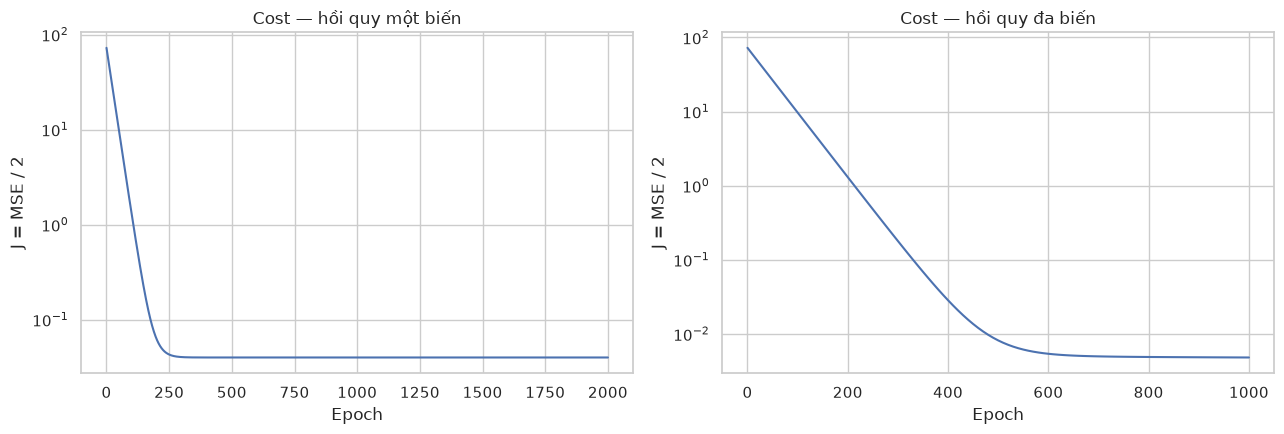

In [17]:
def fit_holdout_model(feature_frame, learning_rate=0.01, epochs=1000):
    preprocessor = HousePreprocessor().fit(feature_frame.iloc[train_indices])
    X_train_matrix = preprocessor.transform(feature_frame.iloc[train_indices])
    X_valid_matrix = preprocessor.transform(feature_frame.iloc[valid_indices])
    model = LinearRegressionGD(
        learning_rate=learning_rate,
        epochs=epochs,
        record_history=True,
        history_interval=10,
    ).fit(X_train_matrix, y_train_log)
    predictions = model.predict(X_valid_matrix)
    return preprocessor, model, predictions


raw_holdout_pre, raw_holdout_model, raw_holdout_pred = fit_holdout_model(raw_features)
eng_holdout_pre, eng_holdout_model, eng_holdout_pred = fit_holdout_model(engineered_features)

holdout_results.append(
    score_row("Linear GD — all raw features", y_valid_log, raw_holdout_pred)
)
holdout_results.append(
    score_row("Linear GD — + 4 engineered", y_valid_log, eng_holdout_pred)
)

holdout_results_df = pd.DataFrame(holdout_results).sort_values("log-RMSE")
display(holdout_results_df.style.format({"log-RMSE": "{:.5f}"}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(cost_1d)
axes[0].set_yscale("log")
axes[0].set_title("Cost — hồi quy một biến")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J = MSE / 2")

axes[1].plot(
    eng_holdout_model.history_epochs_,
    eng_holdout_model.cost_history_,
)
axes[1].set_yscale("log")
axes[1].set_title("Cost — hồi quy đa biến")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("J = MSE / 2")
plt.tight_layout()
plt.show()

## 7. Manual 5-fold cross-validation và chọn hyperparameter

Lưới nhỏ:

- `learning_rate`: `0.005`, `0.01`, `0.02`;
- `epochs`: `1000`, `2000`;
- representation: raw và có bốn engineered features.

Trong từng fold, `HousePreprocessor` và standardization được fit lại chỉ trên bốn folds train. Ta cache các ma trận đã xử lý của từng fold để các cấu hình GD được so sánh trên đúng cùng dữ liệu mà không lặp preprocessing.

Quy tắc chọn:

1. lấy mean CV log-RMSE thấp nhất;
2. các cấu hình cách tốt nhất không quá `0.001` được xem gần hòa;
3. trong nhóm gần hòa, ưu tiên ít epochs hơn, raw features, rồi learning rate nhỏ hơn.

In [18]:
def build_cv_folds(feature_frame, y_values, n_splits=5):
    folds = []
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    for fold_number, (fold_train_idx, fold_valid_idx) in enumerate(
        splitter.split(feature_frame), start=1
    ):
        preprocessor = HousePreprocessor().fit(feature_frame.iloc[fold_train_idx])
        X_fold_train = preprocessor.transform(feature_frame.iloc[fold_train_idx])
        X_fold_valid = preprocessor.transform(feature_frame.iloc[fold_valid_idx])
        folds.append({
            "fold": fold_number,
            "X_train": X_fold_train,
            "X_valid": X_fold_valid,
            "y_train": y_values[fold_train_idx],
            "y_valid": y_values[fold_valid_idx],
        })
    return folds


cv_fold_cache = {
    "raw": build_cv_folds(raw_features, y_log),
    "engineered": build_cv_folds(engineered_features, y_log),
}

for variant, folds in cv_fold_cache.items():
    dimensions = [fold["X_train"].shape[1] for fold in folds]
    print(f"{variant:10s} — số features trong 5 folds: {dimensions}")

raw        — số features trong 5 folds: [280, 278, 275, 275, 279]
engineered — số features trong 5 folds: [284, 282, 279, 279, 283]


In [19]:
def evaluate_gd_config(folds, learning_rate, epochs):
    fold_scores = []
    for fold in folds:
        model = LinearRegressionGD(
            learning_rate=learning_rate,
            epochs=epochs,
            record_history=False,
        ).fit(fold["X_train"], fold["y_train"])
        prediction = model.predict(fold["X_valid"])
        fold_scores.append(log_rmse(fold["y_valid"], prediction))
    return fold_scores


cv_rows = []
for variant, learning_rate, epochs in product(
    ["raw", "engineered"], [0.005, 0.01, 0.02], [1000, 2000]
):
    scores = evaluate_gd_config(
        cv_fold_cache[variant], learning_rate, epochs
    )
    cv_rows.append({
        "variant": variant,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "mean_log_RMSE": np.mean(scores),
        "std_log_RMSE": np.std(scores, ddof=1),
        **{f"fold_{i}": score for i, score in enumerate(scores, start=1)},
    })

cv_results = pd.DataFrame(cv_rows).sort_values("mean_log_RMSE").reset_index(drop=True)
display(
    cv_results.style.format({
        column: "{:.5f}"
        for column in cv_results.columns
        if "RMSE" in column or column.startswith("fold_")
    })
)

,variant,learning_rate,epochs,mean_log_RMSE,std_log_RMSE,fold_1,fold_2,fold_3,fold_4,fold_5
0,raw,0.005000,2000,0.16049,0.04111,0.16076,0.12664,0.22969,0.15251,0.13285
1,raw,0.010000,1000,0.16049,0.04112,0.16076,0.12665,0.22969,0.15251,0.13285
2,raw,0.020000,2000,0.16077,0.04379,0.15910,0.12579,0.23499,0.15274,0.13124
3,raw,0.010000,2000,0.16094,0.04272,0.15979,0.12661,0.23329,0.15264,0.13235
4,raw,0.020000,1000,0.16094,0.04272,0.15979,0.12661,0.23329,0.15264,0.13235
5,engineered,0.020000,2000,0.16098,0.04422,0.15935,0.12552,0.23592,0.15278,0.13131
6,engineered,0.005000,2000,0.16111,0.04227,0.16099,0.12625,0.23248,0.15230,0.13351
7,engineered,0.010000,1000,0.16111,0.04227,0.16100,0.12625,0.23249,0.15230,0.13351
8,engineered,0.010000,2000,0.16129,0.04351,0.16009,0.12625,0.23504,0.15260,0.13248
9,engineered,0.020000,1000,0.16129,0.04351,0.16009,0.12625,0.23504,0.15260,0.13248


In [20]:
best_mean = cv_results["mean_log_RMSE"].min()
near_ties = cv_results[cv_results["mean_log_RMSE"] <= best_mean + 0.001].copy()
near_ties["variant_rank"] = near_ties["variant"].map({"raw": 0, "engineered": 1})
selected = near_ties.sort_values(
    ["epochs", "variant_rank", "learning_rate"]
).iloc[0]

SELECTED_VARIANT = str(selected["variant"])
SELECTED_LEARNING_RATE = float(selected["learning_rate"])
SELECTED_EPOCHS = int(selected["epochs"])

print("Cấu hình có mean CV thấp nhất:")
display(cv_results.head(1))
print("Cấu hình được chọn sau quy tắc near-tie:")
display(selected.drop(labels="variant_rank").to_frame("value"))

mean_baseline_cv_scores = []
splitter = KFold(n_splits=5, shuffle=True, random_state=SEED)
for fold_train_idx, fold_valid_idx in splitter.split(y_log):
    fold_pred = np.full(len(fold_valid_idx), y_log[fold_train_idx].mean())
    mean_baseline_cv_scores.append(log_rmse(y_log[fold_valid_idx], fold_pred))

print(
    f"Mean baseline CV : {np.mean(mean_baseline_cv_scores):.5f} "
    f"± {np.std(mean_baseline_cv_scores, ddof=1):.5f}"
)
print(
    f"Selected OLS CV  : {selected['mean_log_RMSE']:.5f} "
    f"± {selected['std_log_RMSE']:.5f}"
)
assert selected["mean_log_RMSE"] < np.mean(mean_baseline_cv_scores)
assert selected["mean_log_RMSE"] < 0.20

Cấu hình có mean CV thấp nhất:


,variant,learning_rate,epochs,mean_log_RMSE,std_log_RMSE,fold_1,fold_2,fold_3,fold_4,fold_5
0,raw,0.005,2000,0.160489,0.041115,0.160758,0.126644,0.229687,0.152509,0.132846


Cấu hình được chọn sau quy tắc near-tie:


,value
variant,raw
learning_rate,0.01
epochs,1000
mean_log_RMSE,0.16049
std_log_RMSE,0.041116
fold_1,0.16076
fold_2,0.126645
fold_3,0.229691
fold_4,0.152509
fold_5,0.132847


Mean baseline CV : 0.39878 ± 0.02810
Selected OLS CV  : 0.16049 ± 0.04112


## 8. Chẩn đoán mô hình đã chọn trên holdout

CV ở trên dùng để chọn cấu hình. Phần holdout dưới đây nhằm **minh họa** lỗi theo từng căn nhà, không được diễn giải như một test độc lập sau khi đã xem CV.

Ta báo cáo hai không gian:

- log-RMSE để bám mục tiêu mô hình;
- MAE, RMSE, R² sau `expm1` để hiểu sai số bằng USD.

Dự đoán giá âm sau phép nghịch đảo được clip về 0. Đây cũng là quy tắc dùng cho submission.

In [21]:
selected_holdout_frame = (
    raw_features if SELECTED_VARIANT == "raw" else engineered_features
)
selected_holdout_preprocessor = HousePreprocessor().fit(
    selected_holdout_frame.iloc[train_indices]
)
X_selected_train = selected_holdout_preprocessor.transform(
    selected_holdout_frame.iloc[train_indices]
)
X_selected_valid = selected_holdout_preprocessor.transform(
    selected_holdout_frame.iloc[valid_indices]
)
selected_holdout_model = LinearRegressionGD(
    learning_rate=SELECTED_LEARNING_RATE,
    epochs=SELECTED_EPOCHS,
    record_history=True,
    history_interval=10,
).fit(X_selected_train, y_train_log)

selected_valid_pred_log = selected_holdout_model.predict(X_selected_valid)
selected_valid_pred_price = np.maximum(0.0, np.expm1(selected_valid_pred_log))
y_valid_price = y_price[valid_indices]

holdout_log_rmse = log_rmse(y_valid_log, selected_valid_pred_log)
mae_price, mse_price, rmse_price, r2_price = regression_metrics(
    y_valid_price, selected_valid_pred_price
)

diagnostic_metrics = pd.Series({
    "log-RMSE": holdout_log_rmse,
    "MAE (USD)": mae_price,
    "RMSE (USD)": rmse_price,
    "R²": r2_price,
})
display(diagnostic_metrics.to_frame("Holdout metric").style.format("{:,.5f}"))

,Holdout metric
log-RMSE,0.16076
MAE (USD),"16,918.25020"
RMSE (USD),"25,930.33579"
R²,0.91234


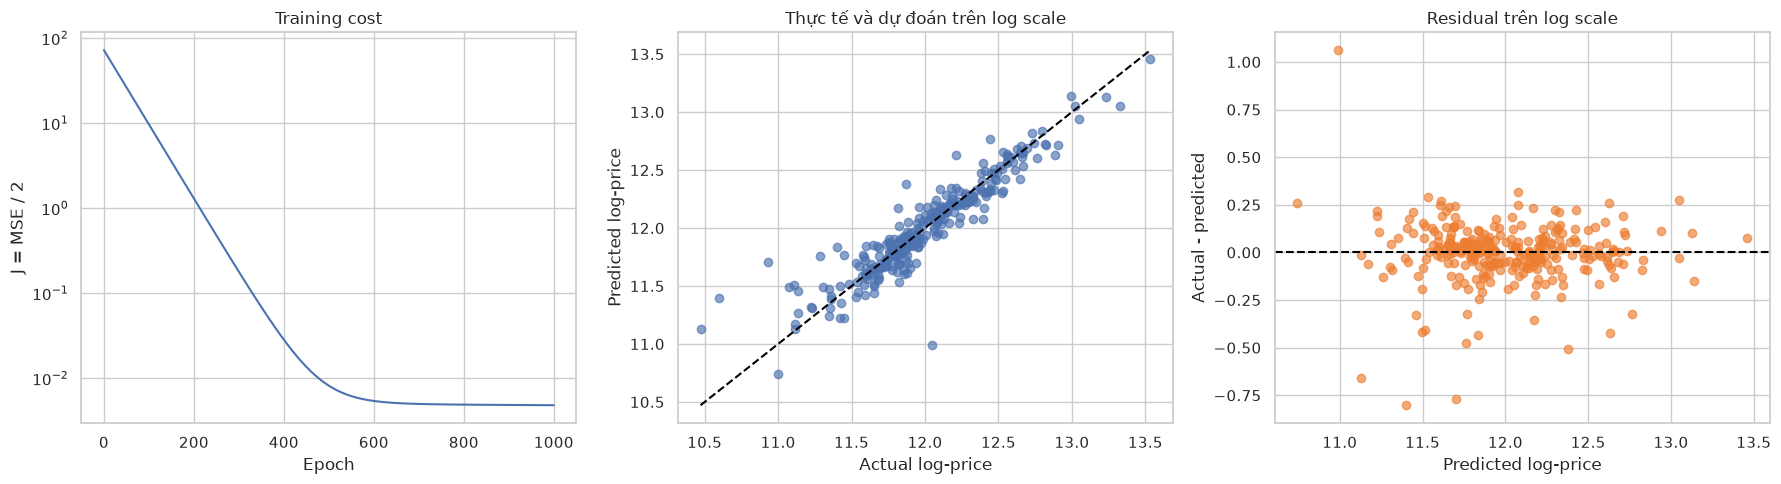

,Id,SalePrice,GrLivArea,OverallQual,Neighborhood,PredictedPrice,AbsLogResidual
1170,1171,171000,1118,6,Mitchel,59116.589445,1.062141
30,31,40000,1317,4,IDOTRR,89203.112243,0.802023
812,813,55993,1044,5,IDOTRR,121127.860057,0.771610
916,917,35311,480,2,IDOTRR,68124.610831,0.657130
588,589,143000,1473,5,ClearCr,237394.172886,0.506875
589,590,79500,935,5,BrkSide,128169.437427,0.477591
479,480,89471,1131,4,OldTown,137879.049587,0.432458
529,530,200624,2515,6,Crawfor,306221.671344,0.422875
1432,1433,64500,968,4,OldTown,98186.861997,0.420202
874,875,66500,1131,5,OldTown,99974.614027,0.407709


In [22]:
residual_log = y_valid_log - selected_valid_pred_log

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(
    selected_holdout_model.history_epochs_,
    selected_holdout_model.cost_history_,
)
axes[0].set_yscale("log")
axes[0].set_title("Training cost")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J = MSE / 2")

axes[1].scatter(y_valid_log, selected_valid_pred_log, alpha=0.65)
low = min(y_valid_log.min(), selected_valid_pred_log.min())
high = max(y_valid_log.max(), selected_valid_pred_log.max())
axes[1].plot([low, high], [low, high], "--", color="black")
axes[1].set_title("Thực tế và dự đoán trên log scale")
axes[1].set_xlabel("Actual log-price")
axes[1].set_ylabel("Predicted log-price")

axes[2].scatter(selected_valid_pred_log, residual_log, alpha=0.65, color="#ED7D31")
axes[2].axhline(0, linestyle="--", color="black")
axes[2].set_title("Residual trên log scale")
axes[2].set_xlabel("Predicted log-price")
axes[2].set_ylabel("Actual - predicted")
plt.tight_layout()
plt.show()

largest_residual_positions = np.argsort(np.abs(residual_log))[-10:][::-1]
residual_cases = train_df.iloc[valid_indices[largest_residual_positions]][
    ["Id", "SalePrice", "GrLivArea", "OverallQual", "Neighborhood"]
].copy()
residual_cases["PredictedPrice"] = selected_valid_pred_price[largest_residual_positions]
residual_cases["AbsLogResidual"] = np.abs(residual_log[largest_residual_positions])
display(residual_cases)

,feature,standardized_coefficient
2,OverallQual,0.059686
14,GrLivArea,0.047427
246,PoolQC=Gd,-0.045319
3,OverallCond,0.035477
11,1stFlrSF,0.032506
4,YearBuilt,0.028750
126,RoofMatl=Tar&Grv,0.027638
12,2ndFlrSF,0.027275
24,GarageCars,0.027004
83,Neighborhood=NridgHt,0.026024


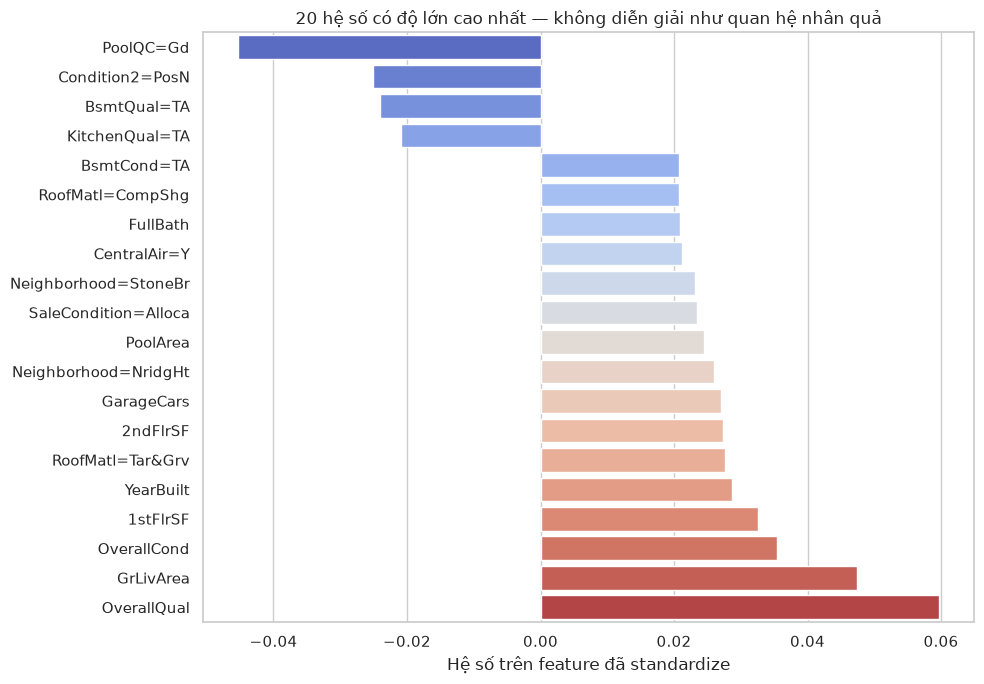

In [23]:
feature_names = selected_holdout_preprocessor.get_feature_names_out()
assert len(feature_names) == len(selected_holdout_model.w_)
coefficient_table = pd.DataFrame({
    "feature": feature_names,
    "standardized_coefficient": selected_holdout_model.w_,
})
coefficient_table["abs_coefficient"] = coefficient_table["standardized_coefficient"].abs()
top_coefficients = coefficient_table.nlargest(20, "abs_coefficient")
display(top_coefficients.drop(columns="abs_coefficient"))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=top_coefficients.sort_values("standardized_coefficient"),
    x="standardized_coefficient", y="feature", hue="feature",
    palette="coolwarm", legend=False,
)
plt.title("20 hệ số có độ lớn cao nhất — không diễn giải như quan hệ nhân quả")
plt.xlabel("Hệ số trên feature đã standardize")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Cách đọc diagnostics

- Cost giảm cho thấy gradient descent đang tối ưu đúng, nhưng cost train giảm không tự động bảo đảm tổng quát hóa tốt.
- Điểm lệch xa đường chéo hoặc residual lớn cho biết nơi giả định tuyến tính chưa mô tả đủ dữ liệu.
- Feature đã standardize nên độ lớn hệ số có thể so tương đối, nhưng one-hot reference và multicollinearity làm hệ số không ổn định. Không dùng bảng này để kết luận nguyên nhân làm giá nhà tăng.
- Độ lệch giữa các folds là thông tin quan trọng: tập dữ liệu nhỏ và outlier có thể làm một split khó hơn hẳn các split khác.

## 9. Fit toàn bộ train và tạo submission

Sau khi representation, learning rate và epochs đã được khóa bằng CV:

1. fit preprocessing lại trên toàn bộ `train.csv`;
2. transform `test.csv` bằng đúng schema đó;
3. fit OLS trên toàn bộ log-target;
4. đổi dự đoán về USD bằng `expm1` và clip tại 0;
5. kiểm tra schema với `sample_submission.csv` trước khi ghi file.

In [24]:
final_train_frame = raw_features if SELECTED_VARIANT == "raw" else engineered_features
final_test_frame = raw_test_features if SELECTED_VARIANT == "raw" else engineered_test_features

final_preprocessor = HousePreprocessor().fit(final_train_frame)
X_full = final_preprocessor.transform(final_train_frame)
X_kaggle_test = final_preprocessor.transform(final_test_frame)

assert X_full.shape[1] == X_kaggle_test.shape[1]
assert np.isfinite(X_full).all() and np.isfinite(X_kaggle_test).all()

final_model = LinearRegressionGD(
    learning_rate=SELECTED_LEARNING_RATE,
    epochs=SELECTED_EPOCHS,
    record_history=True,
    history_interval=10,
).fit(X_full, y_log)

test_pred_log = final_model.predict(X_kaggle_test)
test_pred_price = np.maximum(0.0, np.expm1(test_pred_log))

submission = pd.DataFrame({
    "Id": test_df["Id"].to_numpy(),
    "SalePrice": test_pred_price,
})

assert submission.columns.tolist() == sample_submission.columns.tolist()
assert len(submission) == len(sample_submission) == len(test_df)
assert submission["Id"].equals(sample_submission["Id"])
assert np.isfinite(submission["SalePrice"]).all()
assert (submission["SalePrice"] >= 0).all()

SUBMISSION_PATH = DATA_DIR.parent / "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print("Selected variant      :", SELECTED_VARIANT)
print("Selected learning rate:", SELECTED_LEARNING_RATE)
print("Selected epochs       :", SELECTED_EPOCHS)
print("Final matrix shape    :", X_full.shape)
print("Submission saved to   :", SUBMISSION_PATH.resolve())
display(submission.head())
display(submission["SalePrice"].describe().to_frame())

Selected variant      : raw
Selected learning rate: 0.01
Selected epochs       : 1000
Final matrix shape    : (1460, 282)
Submission saved to   : /home/drago/projects/Machine-Learning-Deep-Learning/House-Price-Prediction/submission.csv


,Id,SalePrice
0,1461,119517.934649
1,1462,155640.090946
2,1463,173732.350929
3,1464,198911.017911
4,1465,200215.837564


,SalePrice
count,1459.000000
mean,178870.175585
std,80541.742621
min,44193.655222
25%,126300.804149
50%,158730.868329
75%,209731.578247
max,928939.644498


## 10. Kết luận

Notebook đã hoàn thành trọn quy trình:

- hiểu target, missing, biến quan trọng và outlier qua EDA;
- tách validation trước mọi preprocessing có học thống kê;
- tự cài standardization, metrics, one-hot schema và linear regression gradient descent;
- đi từ mean baseline đến hồi quy một biến và đa biến;
- đánh giá bằng holdout và manual 5-fold CV;
- chọn hyperparameter bằng quy tắc định trước;
- fit lại toàn bộ train và sinh `submission.csv` hợp lệ.

### Giới hạn cần nhớ

OLS giả định tác động cộng và tuyến tính, nhạy với outlier và không xử lý tốt multicollinearity. Các bước tiếp theo hợp lý—nhưng nằm ngoài phạm vi lời giải đã chọn—là L2/Ridge tự cài đặt, interaction/polynomial có kiểm soát hoặc mô hình cây. Bất kỳ mở rộng nào cũng phải được so sánh bằng cùng quy trình CV và không được dùng Kaggle test để tuning.

### Teach-back checklist

- [ ] Giải thích được vì sao dùng `log1p(SalePrice)`.
- [ ] Chứng minh shape của `X.T @ error / m`.
- [ ] Chỉ ra chính xác thống kê nào chỉ được fit trên train.
- [ ] Phân biệt training cost, holdout metric và CV metric.
- [ ] Giải thích vì sao coefficient không phải bằng chứng nhân quả.
- [ ] Tự mô tả đường đi từ `train.csv` đến `submission.csv`.